# Explorative Datenanalyse (EDA)

**Verwendeter Datensatz**:

Iris Datensatz

Dieser besteht aus Eigenschaften der Blüten verschiedener Lilienarten.
Im Datensatz sind die Eigenschaften der Blüten, die Features, unter data hinterlegt. 
Die Lilienart ist im target kodiert.

**Ziel:**

Es werden auf folgende Fragestellungen eingegangen:

- wie viele Datenpunkte enthält der Datensatz

- wie viele verschiedene Lilienarten sind im Datensatz enthalten

- welche Eigenschaften der Blüten werden notiert


Danach wird ein Streudiagramm der ersten beiden Features, aufgeschlüsselt nach Art der Blüte erstellt.

150
['setosa' 'versicolor' 'virginica']
3
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


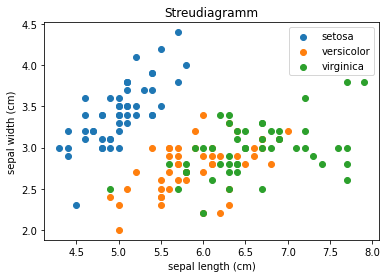

In [12]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

#iris datensatz runterladen
iris = datasets.load_iris()

datenpunkte = iris.data.shape[0]

lilienarten = iris.target_names

lilienarten_anzahl = len(lilienarten)

eigenschaften = iris.feature_names

print(datenpunkte)
print(lilienarten)
print(lilienarten_anzahl)
print(eigenschaften)



for i in range(lilienarten_anzahl):
    x = iris.data[iris.target == i,0]
    y = iris.data[iris.target == i,1]
    plt.scatter(x,y, label=lilienarten[i])



plt.xlabel(eigenschaften[0])
plt.ylabel(eigenschaften[1])
plt.title("Streudiagramm")
plt.legend()

plt.show()

**Verwendeter Datensatz**:

MNIST Datensatz: 

Dieser besteht aus Bilder handgeschriebener Ziffern (0–9).
Die Pixelwerte der 28×28 Bilder sind als Features unter data hinterlegt.
Die jeweilige Ziffer ist im target codiert.

**Ziel:**

Es werden auf folgende Fragestellungen eingegangen:

- Anzahl und Form der Datenpunkte

- Plot der ersten 10 Datenpunkte an


Anzahl und Form Datenpunkte:  (70000, 784)


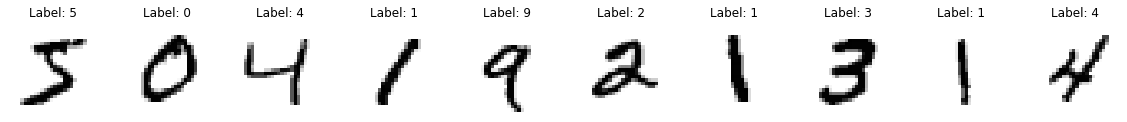

In [23]:
# Import
from sklearn.datasets import fetch_openml

# mnist version
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

x_mnist = mnist.data
y_mnist = mnist.target

print("Anzahl und Form Datenpunkte: ", x_mnist.shape)

# plot erster 10 Datenpunkte
plt.figure(figsize=((20,20)))

for i in range (10):
    plt.subplot(10, 10, i +1)
    plt.imshow(x_mnist[i].reshape(28,28), cmap = "binary")
    plt.title(f"Label: {y_mnist[i]}")
    plt.axis("off")
    
plt.show()


# Mathematische Modelle 

hier werden folgende mathematische Modelle implementiert:



**Logistische Modell**

**Kostenfunktionen**

**Gradientenabstiegsverfahren (Gradient Descent)**


## Logistisches Modell mit zugehörigem Gradienten

Implementierung des Modells

\begin{equation}
    h_\theta(x) = \frac{1}{1 + \exp(-\theta_{0} - \theta_{1}x_1 - \dots - \theta_k x_k) }
\end{equation} 
für den Parametervektor $\theta = \begin{pmatrix}\theta_0\\\theta_1\\\vdots\\\theta_k\end{pmatrix}$

Mit zugehörigem Gradienten (Jacobi-Martrix)

Matrix $G\in\mathbb{R}^{N\times(k+1)}$ mit $G_{i,j} = \frac{\partial h_\theta(x^{(i)})}{\partial \theta_j}$ 

wobei gilt

$\frac{\partial h_\theta(x^{(i)})}{\partial \theta_j}
= h_\theta(x^{(i)}) \left(1 - h_\theta(x^{(i)})\right) x^{(i)}_j$,  
 mit $x^{(i)}_0 = 1$.

In [24]:
def logistic_model(theta):
        
    # wir arbeiten mit numpy
    if not isinstance(theta, np.ndarray):
        theta = np.asarray(theta, dtype= float)
    
    def f(x): 
        if not isinstance(x, np.ndarray):
            x = np.asarray (x, dtype=float)
        # lineare kombination berechnen
        start = theta[0]
        z = start + np.dot (x, theta[1:])

        # in logitische funktion einsetzen und zurückgeben
        z = np.clip (z, -500, 500)
        return  1 / ( 1 + np.exp(-z))
        
    # innere funktion zurückgeben 
    
    return f
        
    
def grad_logistic_model(x,theta):
    
    # logitisches Modell berechnen
    model = logistic_model(theta)
    h = model(x)
    
    # ableitung sigmoid
    o = h * (1 - h)
    
    # matrix erstellen
    zeilen_anzahl = x.shape[0]
    x_bias = np.column_stack([np.ones(zeilen_anzahl),x])
    
    g = o[:, None] * x_bias
    
    return g

## Kostenfunktionen

**mse Kostenfunktion**

\begin{equation}
    J_D(\theta)^{(mse)}=\frac{1}{2N}\sum_{i=1}^{N}{\left(h_\theta(x^{(i)})-y^{(i)}\right)^2}
\end{equation}

mit dem zugehörörigen grad_mse Kostenfunktion

\begin{equation}
    \frac{\partial J_D(\theta)^{(mse)}}{\partial \theta_j}=\frac{1}{N}\sum_{i=1}^{N}{\left(h_\theta(x^{(i)})-y^{(i)}\right) \frac{\partial h_\theta(x^{(i)})}{\partial \theta_j}}
\end{equation}

**bce Kostenfunktion**

mit einer minimalen Verschiebung für numerische Stabilität
\begin{equation}
    J_D(\theta)^{(bce\ stable)}=\frac{1}{N}\sum_{i=1}^{N}{\left(-y^{(i)}\ln(h_\theta(x^{(i)})+\epsilon)-(1-y^{(i)})\ln(1-h_\theta(x^{(i)})+\epsilon)\right)}
\end{equation}

mit dem zugehörörigen grad_bce Kostenfunktion

\begin{equation}
    \frac{\partial J_D(\theta)^{(bce\ stable)}}{\partial \theta_j}=\frac{1}{N}\sum_{i=1}^{N}{
    \left(-\frac{y^{(i)}}{h_\theta(x^{(i)})+\epsilon}+\frac{1-y^{(i)}}{1-h_\theta(x^{(i)})+\epsilon}\right)\frac{\partial h_\theta(x^{(i)})}{\partial \theta_j}}
\end{equation}



In [25]:
def mse_cost_function(x, y, model_fct):
    
    if not isinstance(x, np.ndarray):
        x = np.asarray(x, dtype= float)
        
        
    if not isinstance(y, np.ndarray):
        y = np.asarray(y, dtype= float).reshape(-1)
     
    
    def J(theta):
        
        if not isinstance(theta, np.ndarray):
            theta = np.asarray(theta, dtype= float)
        
        h = model_fct(theta)(x)
        r = h - y
        return 0.5 * np.mean(r**2)
    
    return J
    

def grad_mse_cost_function(x,y,theta,model_fct,model_grad_fct):
   
    if not isinstance(x, np.ndarray):
        x = np.asarray(x, dtype= float)
        
    if not isinstance(y, np.ndarray):
        y = np.asarray(y, dtype= float)
        
    if not isinstance(theta, np.ndarray):
        theta = np.asarray(theta, dtype= float)
    
    N = x.shape[0]
    

    h = model_fct(theta)(x)
    r = h-y
    G = model_grad_fct(x,theta)
    grad = (1.0 / N) * np.dot(r,G)
 
    
    return grad

def bce_cost_function(x, y, model_fct,eps=1E-16):
   
    if not isinstance(x, np.ndarray):
        x = np.asarray(x, dtype= float)
        
    if not isinstance(y, np.ndarray):
        y = np.asarray(y, dtype= float).reshape(-1)
        
    if not np.all((y==0) | (y==1)):
        raise ValueError("y-wert ist für bce nicht gültig")
    
    
    def J(theta):
        
        if not isinstance(theta, np.ndarray):
            theta = np.asarray(theta, dtype= float)
        
        h = model_fct(theta)(x)
        h = np.clip(h, eps, 1 -eps)
        teil_a = - y * np.log ( h)
        teil_b = -(1 - y) * np.log (1 - h)
        
        return np.mean(teil_a + teil_b)
    
    return J

def grad_bce_cost_function(x,y,theta,model_fct,model_grad_fct,eps=1E-16):
  
    if not isinstance(x, np.ndarray):
        x = np.asarray(x, dtype= float)
        
    if not isinstance(y, np.ndarray):
        y = np.asarray(y, dtype= float)
        
    if not isinstance(theta, np.ndarray):
        theta = np.asarray(theta, dtype= float)
        
    N = x.shape[0]
    
    
    h = model_fct(theta)(x)
    teil_a = -y / (h + eps)
    teil_b = (1-y) / (1- h + eps)
    r = teil_a + teil_b
    G = model_grad_fct(x,theta)
    grad = (1.0 / N) * np.dot(r,G)
    
    return grad
    
        
    

## Gradient Descent / Gradientenabstiegverfahren

dieses Verfahren soll universell für verschiedene differenzierbare Modelle und Kostenfunktionen einsetzbar sein.

**Update theta**

Zunächst wird der Update-Schritt implementiert:

\begin{equation}
    \theta_{j}^{(k+1)} \leftarrow \theta_{j}^{(k)} - \alpha * \frac{\partial}{\partial\theta_{j}} J(\theta^{(k)}).
\end{equation}

Anschließend wird das eigentliche Gradientenabstiegverfahren implementiert, bei dem *Update theta* iterativ angewendet wird.



In [26]:
def update_theta(x, y, theta, alpha, cost_grad, model_fct, model_grad_fct):
    
    if not isinstance(theta, np.ndarray):
        theta = np.asarray(theta, dtype= float)
        
    grad = cost_grad(x , y, theta, model_fct, model_grad_fct)
                    
    theta_new = theta - alpha * grad
    
    return theta_new


def gradient_descent(x, y, num_parameters, model_fct, model_grad_fct, cost_fct, cost_grad_fct, epsilon=1E-4, alpha=0.0001, verbose=False, max_iterations=10000):
    
    np.random.seed(42)
    k = 0
    theta = np.random.rand(num_parameters)
    
    grad_norm = np.linalg.norm(cost_grad_fct(x,y,theta,model_fct,model_grad_fct))

    cost = cost_fct(x,y,model_fct)
    
    theta_hist = [theta]
    cost_hist = [cost(theta)]
    
    while grad_norm > epsilon and k < max_iterations:
        theta = update_theta(x,y,theta,alpha,cost_grad_fct,model_fct,model_grad_fct)
        theta_hist.append(theta)
        cost_hist.append(cost(theta))
        grad_norm = np.linalg.norm(cost_grad_fct(x,y,theta,model_fct,model_grad_fct))
        k += 1

    if verbose:
        print(f'final result\n\tcost: {cost(theta)}\n\t$\\theta$: {theta}\n\tnumber of iterations: {k}\n\tgradient norm: {grad_norm}')
    return cost_hist,theta_hist

    


## Verwendung des logistischen Modells

Es wird eine logistische Funktion mit einem gewählten Parametervektor
θ erzeugt und in einem Konturplot gemeinsam mit den ersten beiden Features des Iris-Datensatzes in einem Streudiagramm dargestellt.

**Ziel**

Ziel ist die Visualisierung des Einflusses des Parametervektors 
θ auf die Form der logistischen Funktion sowie auf die Lage der daraus resultierenden Entscheidungsgrenze im zweidimensionalen Feature-Raum.



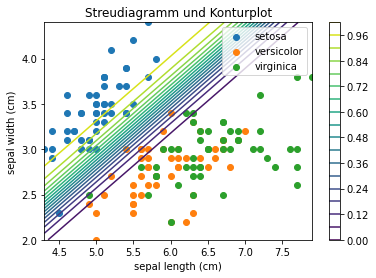

In [27]:
# theta vektor erstellen array

theta = [5, -5, 7] # erklärem??
model = logistic_model(theta)

x_all = iris.data[:,0]
y_all = iris.data[:,1]


X,Y = np.meshgrid(np.linspace(x_all.min(), x_all.max()),
                  np.linspace(y_all.min(), y_all.max()))

Z = model(np.c_[X.ravel(), Y.ravel()]).reshape(X.shape)


#Iris daten
for i in range(lilienarten_anzahl):
    x = iris.data[iris.target == i,0]
    y = iris.data[iris.target == i,1]
    plt.scatter(x,y, label=lilienarten[i])

plt.xlabel(eigenschaften[0])
plt.ylabel(eigenschaften[1])
plt.title("Streudiagramm und Konturplot")
plt.legend()

#konturplot
plt.contour(X,Y,Z, levels = 18)
plt.colorbar()


plt.show()

### Erklärung des Plotts

Die farbigen Linien stammen von der logistischen Funktion.
Sie stellen verschiedene Wahrscheinlichkeitsniveaus zwischen 0 und 1 dar.
Dunklere Bereiche entsprechen höheren Modellwahrscheinlichkeiten,
hellere Bereiche niedrigeren Wahrscheinlichkeiten.

Die Linie bei einem Wahrscheinlichkeitswert von 0.5 bildet die Entscheidungsgrenze des Modells. Damit trennt diese Linie den Feature-Raum in zwei Klassifikationsbereiche.

Es wird keine optimierte Klassifikation dargestellt, da die Parameter
θ nicht durch Training bestimmt wurden.






## Untersuchung der Kostenlandschaften

Hier werden die Kostenfuntkionen BCE und MSE miteinader verglichen.
Dafür werden die Kosten für viele Kombinationen der Paramter (theta schreibweise) 1 und 2 berechnet.

**Ziel**
Das Ziel ist es, optisch zu prüfen, welche Funktionen den einfachsten Weg zum kleinsten Fehler zeigen.

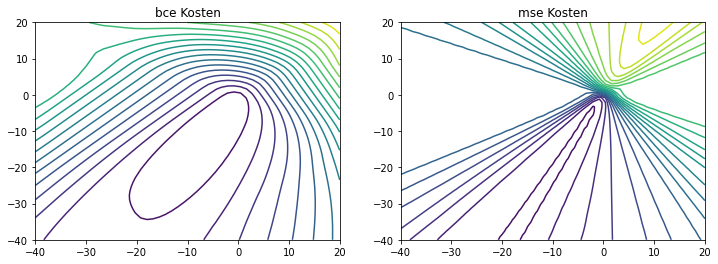

In [28]:
x_raw = iris.data
y_raw = iris.target

x = x_raw[:,0:1].reshape(-1,1)
y = (y_raw == 0).astype(float)

x_teil_a = np.mean(x, axis = 0)
x_teil_b = np.std(x, axis = 0)
x = (x - x_teil_a)/( x_teil_b)

#anzahl param, also theta 0 theta 1
num_parameters = 2

J_bce_cost = bce_cost_function(x,y,logistic_model)
J_mse_cost = mse_cost_function(x,y,logistic_model)

#Gitter
theta_0 = np.linspace(-40, 20)
theta_1 = np.linspace(-40, 20)

theta_0, theta_1 = np.meshgrid(theta_0, theta_1)

bce = np.zeros_like(theta_0)
mse = np.zeros_like(theta_0)

for i in range(theta_0.shape[0]):
    for j in range (theta_0.shape[1]):
        theta = np.array([theta_0[i,j], theta_1[i,j]])
        bce[i,j] = J_bce_cost(theta)
        mse[i,j] = J_mse_cost(theta)
        

#plot
fig, costplt = plt.subplots(1,2, figsize= (12,4))

costplt[0].contour(theta_0, theta_1, bce, levels=20)
costplt[0].set_title("bce Kosten")

costplt[1].contour(theta_0, theta_1, mse, levels = 20)
costplt[1].set_title("mse Kosten")

    
plt.show()

### Auswertung der Ergebnisse

Der BCE-Plot zeigt eine glatte elliptisch förmige Landschaft.
Das Modell findet von jedem Startpunkt aus schnell und direkt den Weg zum Ziel (globales Minimum).

Der MSE-Plot zeigt eine unebene Landschaft mit flachen Bereichen.
DasModell bleibt leicht stecken, da es in der flachen Ebene keine Richtung mehr für die minimierung findet

**Fazit**

Die Visualisierung bestätigt, dass BCE für Klassifikationsaufgaben deutlich besser ist, da der Lernprozess stabil und zielgerichtet verläuft

## Verwendung des Gradient descent

Das Modell wird mit dem Gradient Descent trainiert.
Dafür werden die ersten zwei Merkmale der Iris-Daten benutzt.
Das Training wird zwei mal durchgeführt, einmam mit BCE und einmal mit MSE. 
Dabei wird die Lernrate alpha = 0.01 gesetzt und es werden maximal 1000 iterationen durchgeführt.

In [37]:
mask = (y == 0) | (y == 1)
x = x[mask, :2]  # erste beiden Features
y = y[mask]




cost_hist_bce = gradient_descent(x, y,x.shape[1]+1,
                                     logistic_model,
                                     grad_logistic_model,
                                     bce_cost_function,
                                     grad_bce_cost_function, epsilon=0.01, alpha=0.01, verbose=True,max_iterations=1000)

cost_hist_mse= gradient_descent(x, y,x.shape[1]+1,
                                     logistic_model,
                                     grad_logistic_model,
                                     mse_cost_function,
                                     grad_mse_cost_function, epsilon=0.001, alpha=0.01, verbose=True,max_iterations=1000)

final result
	cost: 0.3563987118946309
	$\theta$: [-0.69182738 -1.36334922]
	number of iterations: 1000
	gradient norm: 0.1091838125499315
final result
	cost: 0.1236398196073468
	$\theta$: [-0.05127867  0.0081868 ]
	number of iterations: 1000
	gradient norm: 0.09329880960024531


# Linearer SVM Klassifikator mit MNIST

**Vorgehensweise**

In diesem Abschnitt werden folgende Punkte untersucht:

- Effekt der Trainingsdatensatzgröße für verschiedene Kernel-Funktionen

- Rolle des Hyperparameters  𝐶 für das Training einer SVM

Auf Baises dieser Untersuchung wird versucht ein möglichst optimaler SVM Klassifikator auf die MNIST-Daten zu trainieren

**Festlegung der Daten**
Es wird ein fester Validierungssatz der Größe 10000 festgelegt.
Zusätzlich gibt es eine funktion die die Anzahl der Trainingsdatenpunkte als übergeben bekommt und diese vom Beginn des Datensatzes her abspaltet. 
Dabei wird sicher gestellt, dass keine Datenpunkte aus den Validierungsdaten in den Trainingsdaten erscheinen.

In [30]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, metrics, svm
from sklearn.datasets import fetch_openml
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
# fester Validierungssatz 
anzahl_val = 10000
x_val = x_mnist[-anzahl_val:]
y_val = y_mnist[-anzahl_val:]

# gibt daten zum trainieren zurück
def get_train_data (x, y, anzahl_daten):
    max_anzahl = len(x) - anzahl_val 
    
    if anzahl_daten > max_anzahl:
        raise ValueError("Überschneidung mit Validierungsdaten")
    
    return x[:anzahl_daten], y[:anzahl_daten]


## Effekt der Trainingsdatensatzgröße für verschiedene Kernel-Funktionen

...

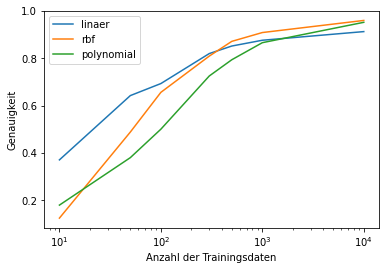

In [32]:
# Größen für Trainingdaten
train_size = [10,50,100,300,500,1000,10000]

# Kernelfuntionen default versionen:

# linear 
linear_kernel = SVC(kernel="linear")

# polynomial
polynomial_kernel = SVC(kernel = "poly")

# RBF
rbf_kernel = SVC(kernel = "rbf")

# zum speichern
acc_linear =[]
acc_polynomial =[]
acc_rbf =[]

# Schleife damit alle train_size durchgegangen werden
for i in train_size:

    # trianingsdaten der größe n speichern
    x_train, y_train = get_train_data (x_mnist, y_mnist, anzahl_daten = i)
    
    # Modelle mit Trainingsdaten trainieren und validieren
    linear_kernel.fit(x_train, y_train)
    acc_linear.append(linear_kernel.score(x_val, y_val))
    
    polynomial_kernel.fit(x_train, y_train)
    acc_polynomial.append(polynomial_kernel.score(x_val, y_val))
    
    rbf_kernel.fit(x_train, y_train)
    acc_rbf.append(rbf_kernel.score(x_val, y_val))
    
# Plot erstellen
plt.figure()

plt.plot(train_size, acc_linear, label="linaer")
plt.plot(train_size, acc_rbf, label="rbf")
plt.plot(train_size, acc_polynomial, label="polynomial")

plt.xscale("log")
plt.xlabel("Anzahl der Trainingsdaten")
plt.ylabel("Genauigkeit")
plt.legend()
plt.show()

# Disskusion
# die Genauigkeit steigt idR mit der Anzahl der Trainingdaten
# d.h man kann eine höhere Genaugkeit erwarten, wenn man mehr Trainingsdaten verwerdent,
# jedoch ist dieser Wachstum nicht linear sondern ab eine Gewisse Anzahl ist
# diese effekt nicht mehr so groß 
# vor allem im Bereiech 10^1 bis 10^3 lohnt es sich mehr Trainingsdaten zu verwenden
# Grund für diese Beobachtung könnte zu einem Over-fitting sein, da wenige Daten
# dazu führen können, ab einer gewissen Größe von Traningsdaten geht man der
# Gefahr zum 'over-fitten' aus dem Weg. 

## Rolle des Hyperparameters 𝐶 für das Training einer SVM


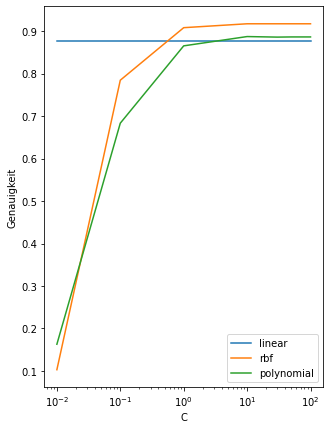

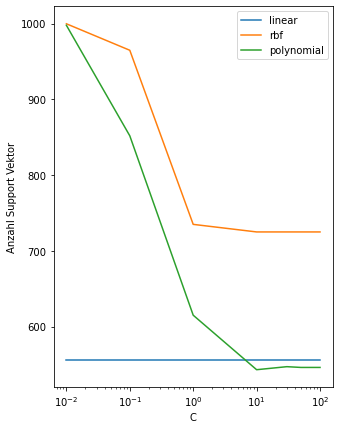

In [34]:
train_size = 1000

param_c = [0.01, 0.1, 1, 10, 30, 50, 70, 100]

x_train, y_train = get_train_data (x_mnist, y_mnist, anzahl_daten = train_size )

# zum accuracy speichern
acc_linear =[]
acc_polynomial =[]
acc_rbf =[]

# zum supervektoren speichern
sv_linear =[]
sv_polynomial =[]
sv_rbf =[]
 
    
# Schleife um verschiedene C werte einzusetzen
for i in param_c:
    # Kernelfuntionen :
    # linear 
    linear_kernel = SVC(kernel= "linear", C = i)

    # polynomial
    polynomial_kernel = SVC(kernel = "poly", C = i )

    # RBF
    rbf_kernel = SVC(kernel = "rbf", C = i)

    # Modelle mit Trainingsdaten trainieren/validieren/sv speichern
    linear_kernel.fit(x_train, y_train)
    acc_linear.append(linear_kernel.score(x_val, y_val))
    sv_linear.append(linear_kernel.n_support_.sum())
    
    polynomial_kernel.fit(x_train, y_train)
    acc_polynomial.append(polynomial_kernel.score(x_val, y_val))
    sv_polynomial.append(polynomial_kernel.n_support_.sum())
    
    rbf_kernel.fit(x_train, y_train)
    acc_rbf.append(rbf_kernel.score(x_val, y_val))
    sv_rbf.append(rbf_kernel.n_support_.sum())
    
# Plots erstellen

# Accuracy
plt.figure(figsize=(5,7))
plt.plot(param_c, acc_linear, label ="linear")
plt.plot(param_c, acc_rbf, label ="rbf")
plt.plot(param_c, acc_polynomial, label ="polynomial")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Genauigkeit")
plt.legend()
plt.show()

# Support Vektor Anzahl
plt.figure(figsize=(5,7))
plt.plot(param_c, sv_linear, label ="linear")
plt.plot(param_c, sv_rbf, label ="rbf")
plt.plot(param_c, sv_polynomial, label ="polynomial")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Anzahl Support Vektor")
plt.legend()
plt.show()



## Training des optimalen SVM Klassifikator 

mit dem erwobenen Wissen wird nun ein optimaler SVM Klassifikator trainiert.

Dieser wird mit folgenden Metriken bewertet:

- Accuracy
- Confusion Matrix

Zusätzlich werden die ersten 100 Fehlklassifikationen angezeigt.

### Wahl Erklärung:

Kernel = rbf, weil es im Plot im vergleich zu anderen Kernels die höchste accuracy aufzeigt (bei 10^4 Trainingsdaten)

C = 5.0, weil danach kein signifikanter anstieg zu sehen war

Accuracy:  0.9679


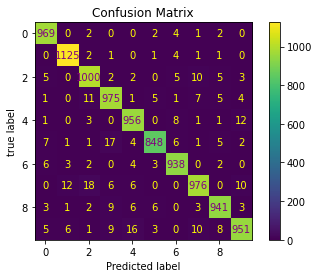

Plot der ersten 100 Fehlklassifikationen (von 321 vielen):


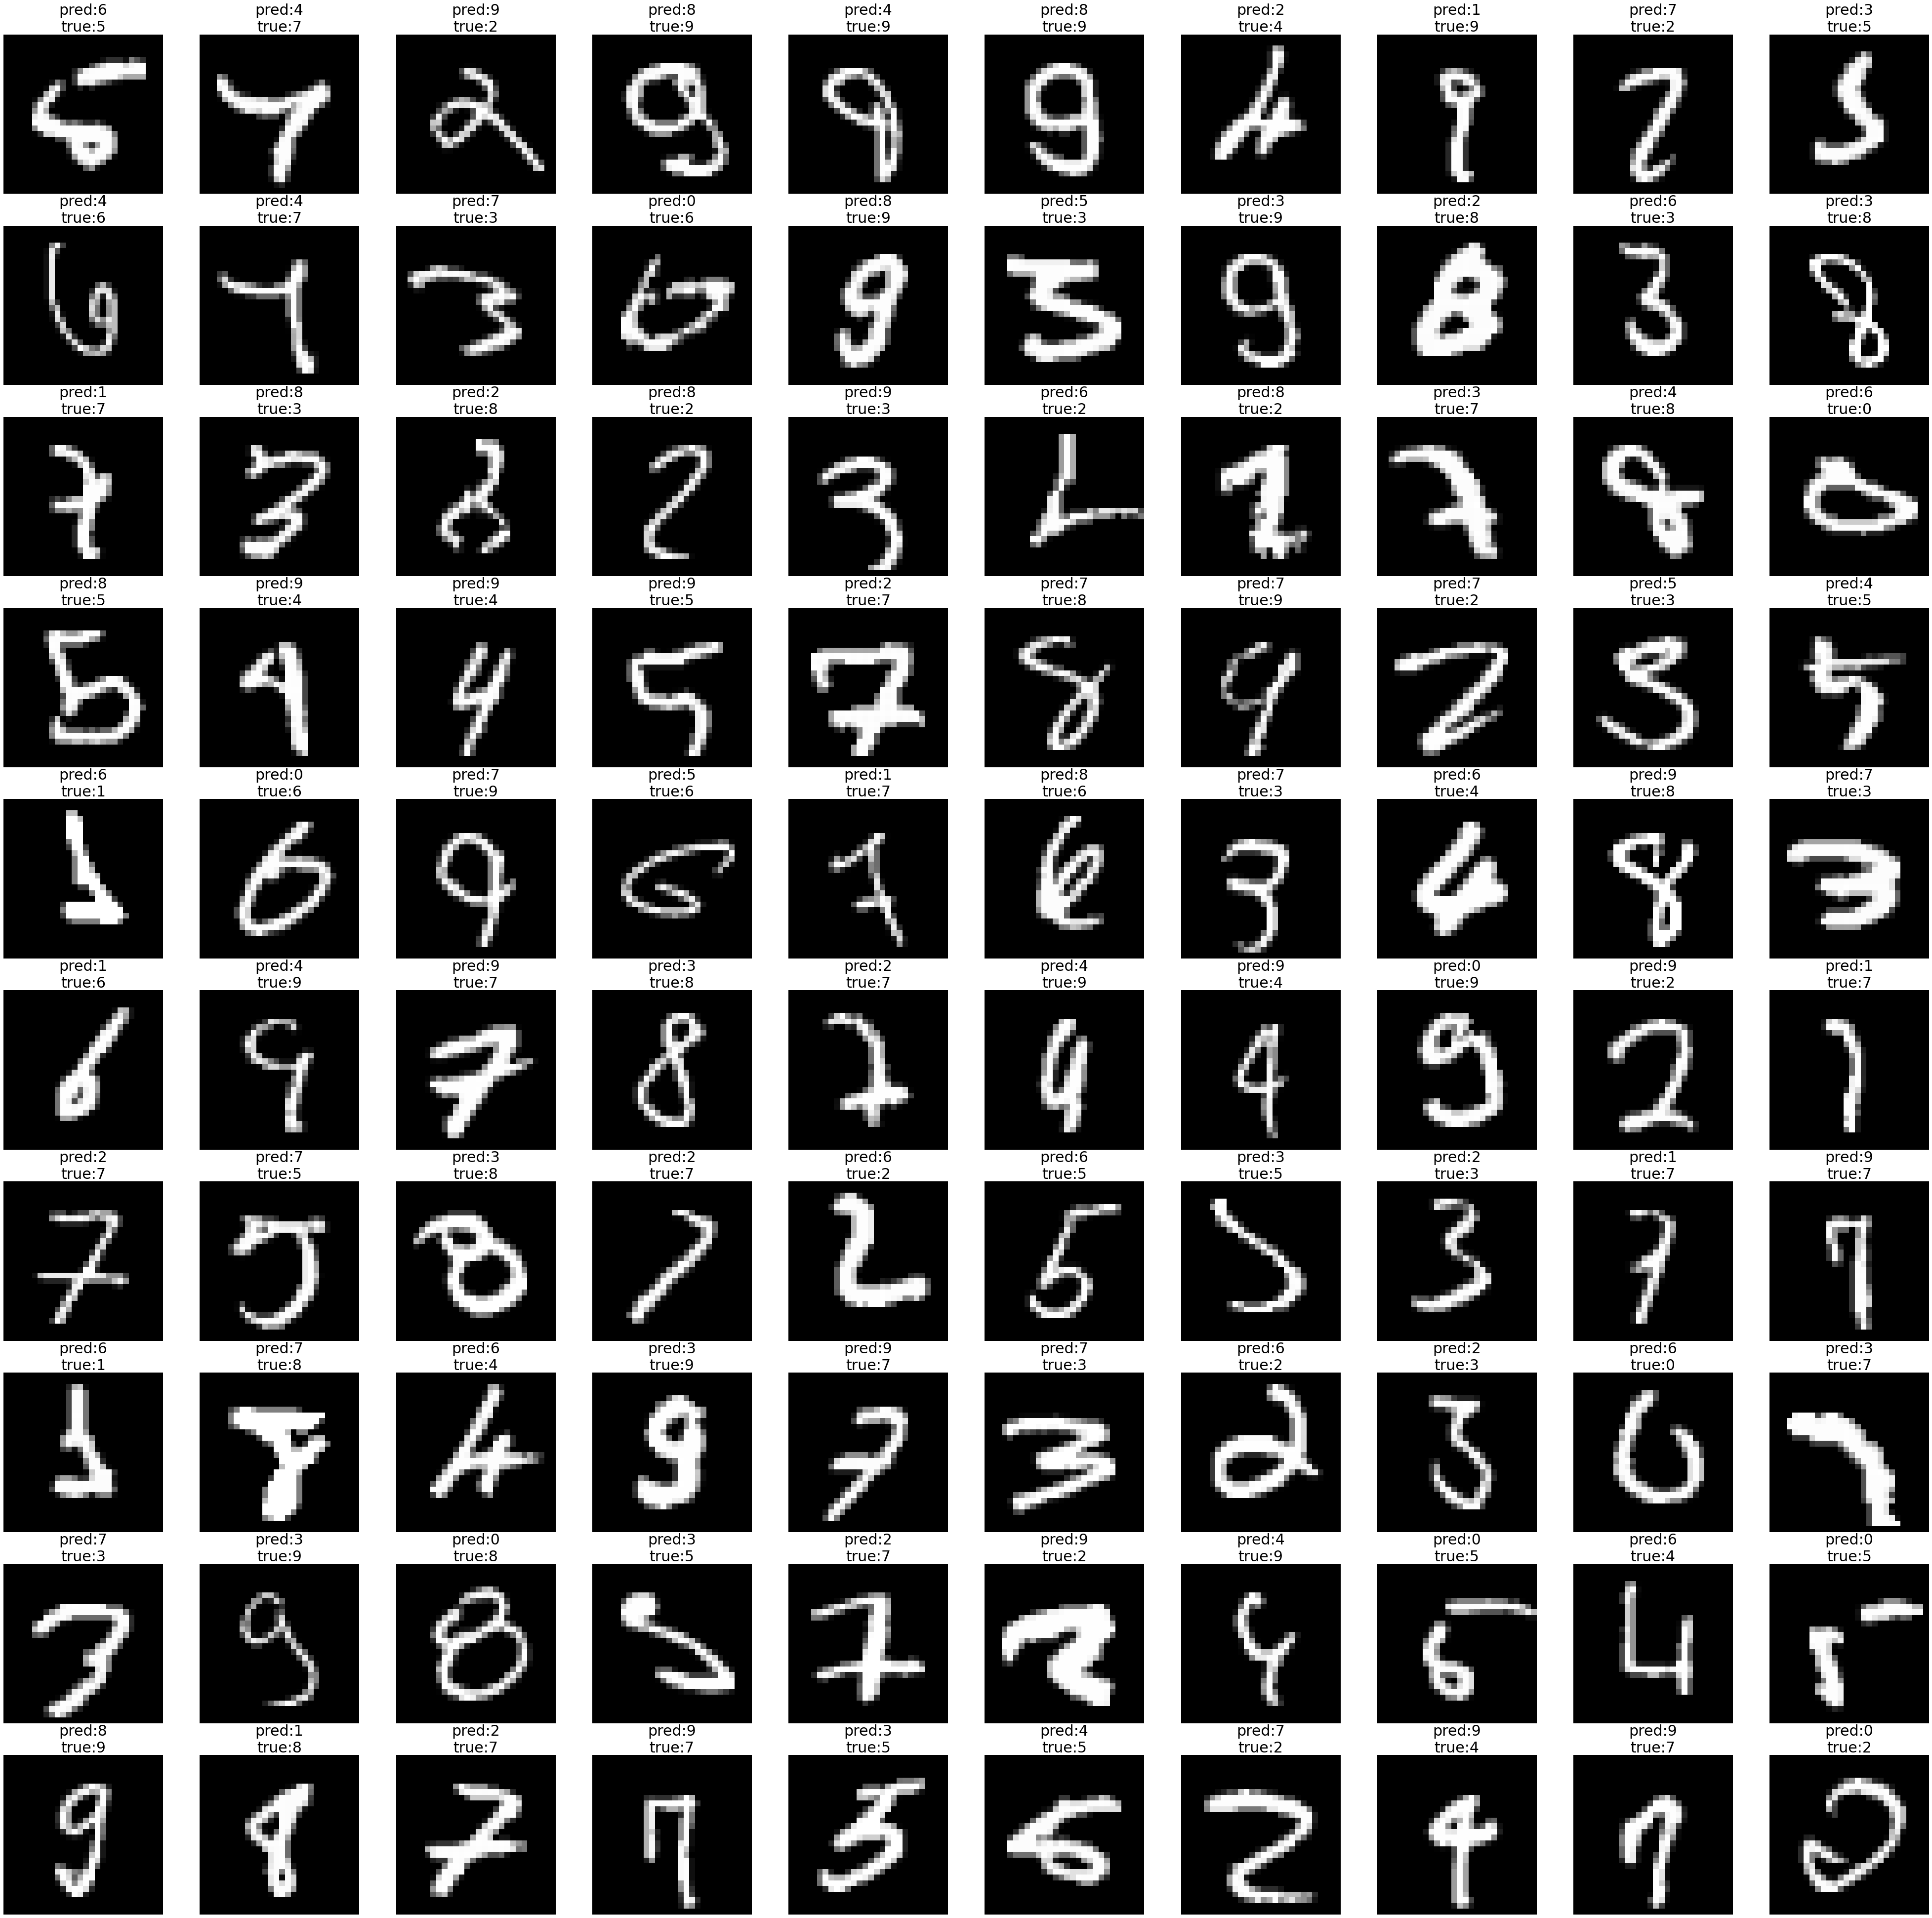

In [35]:
# Trainingsdaten
anz = 10000
x_train, y_train = get_train_data (x_mnist, y_mnist, anzahl_daten = anz )

# modell wählen und C-param
c_param = 5.0
kernel = "rbf"
clf = SVC(kernel = kernel, C = c_param)

# modell trainieren
clf.fit( x_train, y_train)

# validierung
y_pred = clf.predict(x_val)
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy: ", accuracy)

# indiz der fehlerhaften klassifizierte Daten (nicht die Bilder selbst)
fehler_daten = np.where(y_pred != y_val)[0]
anz_fehler_daten = len (fehler_daten)

# Confusiom Matrix

# Diagramm Confusion matrix
cm = confusion_matrix(y_val, y_pred)

# PLot erstellen
plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted label")
plt.ylabel("true label")
plt.title("Confusion Matrix")


for i in range(cm.shape[0]):
    for j in range (cm.shape[1]):
        plt.text(
            j, i , cm[i, j],
            ha = "center", va ="center",
            color="purple" if cm[i, j] > cm.max() / 2 else "yellow"
        )

plt.show()

# plot für fehlerhafte beispiele
anz_bsp = 100

# falls weniger fehler vorhanden als man ausgeben will
if (anz_bsp > anz_fehler_daten):
    anz_bsp = anz_fehler_daten
    
fehler_daten_show = fehler_daten[:anz_bsp]

plt.figure(figsize=((70,70)))

for i,j in enumerate(fehler_daten_show):
    plt.subplot(10, 10, i+1)
    plt.imshow(x_val[j].reshape(28,28), cmap="gray")
    plt.title(f"pred:{y_pred[j]}\ntrue:{y_val[j]}", fontsize = 30)
    plt.axis("off")
    
print(f"Plot der ersten {anz_bsp} Fehlklassifikationen (von {anz_fehler_daten} vielen):")
plt.show()